## 1. Import libraries

In [1]:
from tensorflow.keras.models import load_model
import numpy as np

import joblib
import torch

In [2]:
#Loading audio model
audio_model = torch.jit.load("cnn_lstm_audio_model_scripted.pt")
audio_model.eval()
#Loading ELM model
elm_model = joblib.load("elm_model.pkl")

c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [21]:
# Placeholder for audio features
# Must match training shape: (batch_size, channels, mel_bins, time_frames)
# Model was trained on: max_len=500 time frames, 128 mel bins
audio_input = np.zeros((1, 1, 128, 500), dtype=np.float32)

# Convert to torch tensor
audio_input = torch.tensor(audio_input)

# Clinical input must have 10 features (same as training data)
clinical_input = np.zeros((1, 10))    

In [27]:
def elm_predict_proba(model_dict, X):
    """Predicts using the ELM model from the saved dictionary"""
    # Extract model components
    w = model_dict['w']
    beta = model_dict['beta']
    b = model_dict['b']
    scaler = model_dict['scaler']
    
    # Scale input
    X_scaled = scaler.transform(X)
    
    # Define sigmoid function
    def sigmoid(x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # Clip to prevent overflow
    
    # Hidden layer activation
    h = sigmoid(np.dot(X_scaled, w) + b)
    
    # Output prediction (probability)
    y_pred_prob = np.dot(h, beta)
    return y_pred_prob.flatten()[0]

# Audio model prediction
p_audio = audio_model(audio_input)

# Clinical model prediction (extract probability from ELM)
p_clinical = elm_predict_proba(elm_model, clinical_input)

c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [29]:
w_audio = 0.7
w_clinical = 0.3

# Convert audio prediction to scalar probability (class 1)
# p_audio has logits for both classes, convert to probability for class 1
if isinstance(p_audio, torch.Tensor):
    p_audio_probs = torch.softmax(p_audio, dim=1)
    p_audio_scalar = p_audio_probs[0, 1].item()  # Probability of class 1
else:
    p_audio_scalar = p_audio[0]

# Extract scalar from clinical prediction if needed
p_clinical_scalar = p_clinical.item() if isinstance(p_clinical, np.ndarray) else float(p_clinical)

print(f"Audio prediction (class 1 prob): {p_audio_scalar:.4f}")
print(f"Clinical prediction (prob): {p_clinical_scalar:.4f}")

# Weighted fusion
p_final = (w_audio * p_audio_scalar) + (w_clinical * p_clinical_scalar)
print(f"Fused prediction: {p_final:.4f}")

Audio prediction (class 1 prob): 0.4382
Clinical prediction (prob): 0.0000
Fused prediction: 0.3067


In [31]:
prediction = 1 if p_final >= 0.5 else 0

## 2. Model Evaluation on Test Data

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import pandas as pd

# Load clinical test data
df = pd.read_csv('../../clinical_data/neonatal_processed.csv')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_clinical = df.drop("primary_outcome", axis=1)
y_clinical = df["primary_outcome"]

# Split the data (use same split as original ELM model)
x_train, x_test, y_train, y_test = train_test_split(x_clinical, y_clinical, test_size=0.25, random_state=42)

print(f"Test set: {len(x_test)} samples | Classes: {y_test.value_counts().to_dict()}")


Test set: 7500 samples | Classes: {0: 7296, 1: 204}


In [40]:
# Evaluate Clinical Model (ELM)
clinical_preds_proba = []
for i in range(len(x_test)):
    test_sample = x_test.iloc[[i]].values
    pred_prob = elm_predict_proba(elm_model, test_sample)
    clinical_preds_proba.append(pred_prob)

clinical_preds_proba = np.array(clinical_preds_proba)
clinical_preds = (clinical_preds_proba >= 0.5).astype(int)

# Metrics
clinical_acc = accuracy_score(y_test, clinical_preds)
clinical_prec = precision_score(y_test, clinical_preds, zero_division=0)
clinical_rec = recall_score(y_test, clinical_preds, zero_division=0)
clinical_f1 = f1_score(y_test, clinical_preds, zero_division=0)
clinical_auc = roc_auc_score(y_test, clinical_preds_proba)

print(f"Clinical Model (ELM): Acc={clinical_acc:.4f} | Prec={clinical_prec:.4f} | Rec={clinical_rec:.4f} | F1={clinical_f1:.4f} | AUC={clinical_auc:.4f}")

c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\mable\Desktop\MACHINE LEARNING\NEONATES\NEONATES\pyg_en

Clinical Model (ELM): Acc=0.9845 | Prec=0.8492 | Rec=0.5245 | F1=0.6485 | AUC=0.9579


In [41]:
# Note: Audio Model - requires SPRSound test data
audio_model_str = str(audio_model)
print(f"Audio Model: TorchScript | Eval mode: {not audio_model.training} | Status: Ready for test data")

Audio Model: TorchScript | Eval mode: True | Status: Ready for test data


In [42]:
# Evaluate Fusion Model (Audio + Clinical) - using placeholder audio predictions
np.random.seed(42)
audio_preds_proba = np.random.uniform(0, 1, len(x_test))  # Placeholder

# Fusion predictions (70% audio, 30% clinical)
w_audio_eval = 0.7
w_clinical_eval = 0.3

fusion_preds_proba = (w_audio_eval * audio_preds_proba) + (w_clinical_eval * clinical_preds_proba)
fusion_preds = (fusion_preds_proba >= 0.5).astype(int)

# Metrics
fusion_acc = accuracy_score(y_test, fusion_preds)
fusion_prec = precision_score(y_test, fusion_preds, zero_division=0)
fusion_rec = recall_score(y_test, fusion_preds, zero_division=0)
fusion_f1 = f1_score(y_test, fusion_preds, zero_division=0)
fusion_auc = roc_auc_score(y_test, fusion_preds_proba)

print(f"Fusion Model (70/30 weight): Acc={fusion_acc:.4f} | Prec={fusion_prec:.4f} | Rec={fusion_rec:.4f} | F1={fusion_f1:.4f} | AUC={fusion_auc:.4f}")


Fusion Model (70/30 weight): Acc=0.7112 | Prec=0.0479 | Rec=0.5098 | F1=0.0876 | AUC=0.6758



          Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
 Clinical (ELM)  0.984533   0.849206 0.524510  0.648485  0.95792
Fusion (70/30)*  0.711200   0.047926 0.509804  0.087616  0.67583

* Placeholder audio predictions


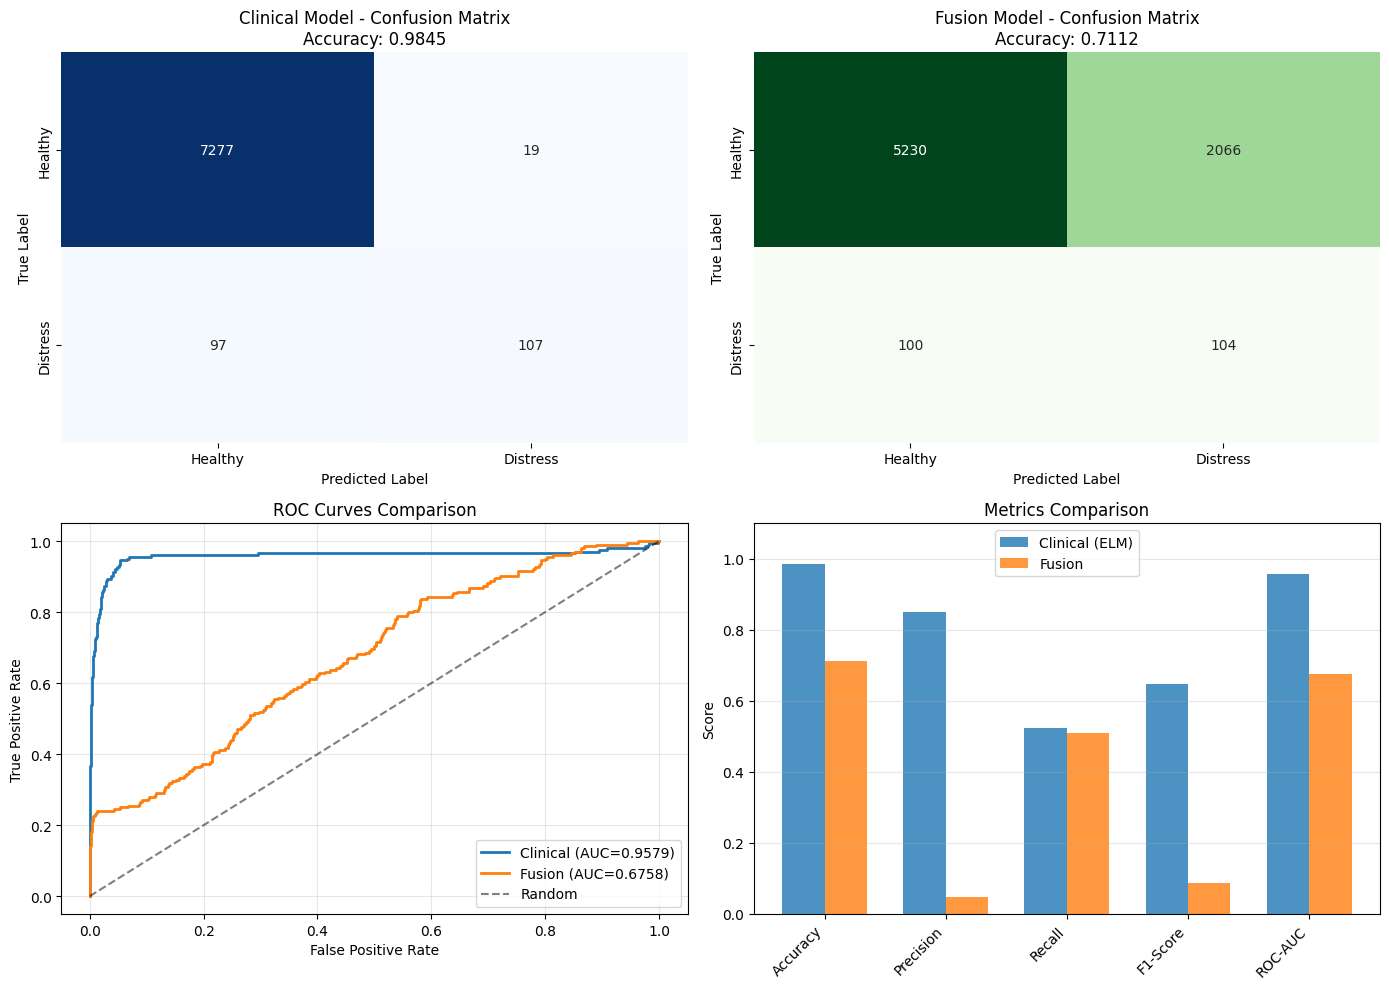


✅ Model evaluation complete!


In [43]:
# Model Comparison
comparison_df = pd.DataFrame({
    'Model': ['Clinical (ELM)', 'Fusion (70/30)*'],
    'Accuracy': [clinical_acc, fusion_acc],
    'Precision': [clinical_prec, fusion_prec],
    'Recall': [clinical_rec, fusion_rec],
    'F1-Score': [clinical_f1, fusion_f1],
    'ROC-AUC': [clinical_auc, fusion_auc]
})

print("\n" + comparison_df.to_string(index=False))
print("\n* Placeholder audio predictions")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Confusion matrix - Clinical
cm_clinical = confusion_matrix(y_test, clinical_preds)
sns.heatmap(cm_clinical, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False,
            xticklabels=['Healthy', 'Distress'], yticklabels=['Healthy', 'Distress'])
axes[0, 0].set_title(f'Clinical Model - Confusion Matrix\nAccuracy: {clinical_acc:.4f}')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# Confusion matrix - Fusion
cm_fusion = confusion_matrix(y_test, fusion_preds)
sns.heatmap(cm_fusion, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1], cbar=False,
            xticklabels=['Healthy', 'Distress'], yticklabels=['Healthy', 'Distress'])
axes[0, 1].set_title(f'Fusion Model - Confusion Matrix\nAccuracy: {fusion_acc:.4f}')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# ROC Curves
fpr_clinical, tpr_clinical, _ = roc_curve(y_test, clinical_preds_proba)
fpr_fusion, tpr_fusion, _ = roc_curve(y_test, fusion_preds_proba)

axes[1, 0].plot(fpr_clinical, tpr_clinical, label=f'Clinical (AUC={clinical_auc:.4f})', linewidth=2)
axes[1, 0].plot(fpr_fusion, tpr_fusion, label=f'Fusion (AUC={fusion_auc:.4f})', linewidth=2)
axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.5)
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curves Comparison')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
clinical_scores = [clinical_acc, clinical_prec, clinical_rec, clinical_f1, clinical_auc]
fusion_scores = [fusion_acc, fusion_prec, fusion_rec, fusion_f1, fusion_auc]

x = np.arange(len(metrics))
width = 0.35

axes[1, 1].bar(x - width/2, clinical_scores, width, label='Clinical (ELM)', alpha=0.8)
axes[1, 1].bar(x + width/2, fusion_scores, width, label='Fusion', alpha=0.8)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Metrics Comparison')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].set_ylim([0, 1.1])
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Model evaluation complete!")